<a href="https://colab.research.google.com/github/lindlabs/TelecomX-Churn-Analysis/blob/main/TelecomX_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import requests

# URL del archivo JSON en formato raw
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Carga de datos directamente desde la fuente
try:
    response = requests.get(url)
    data = response.json()

    # Conversión a DataFrame de Pandas
    df = pd.DataFrame(data)

    # Verificación inicial de la carga
    print("Datos cargados exitosamente.")
    print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
    display(df.head())

except Exception as e:
    print(f"Error al cargar los datos: {e}")

Datos cargados exitosamente.
Filas: 7267 | Columnas: 6


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [2]:
# 1. Explorar la estructura general y tipos de datos
print("--- Información General del Dataset ---")
df.info()

# 2. Verificar tipos de datos de forma resumida
print("\n--- Tipos de Datos por Columna ---")
print(df.dtypes)

# 3. Explorar el contenido de las columnas con diccionarios (anidadas)
# Esto es necesario para identificar las variables relevantes dentro de cada categoría
print("\n--- Ejemplo de datos anidados en 'customer' ---")
print(df['customer'].iloc[0])

print("\n--- Ejemplo de datos anidados en 'account' ---")
print(df['account'].iloc[0])

--- Información General del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB

--- Tipos de Datos por Columna ---
customerID    object
Churn         object
customer      object
phone         object
internet      object
account       object
dtype: object

--- Ejemplo de datos anidados en 'customer' ---
{'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'tenure': 9}

--- Ejemplo de datos anidados en 'account' ---
{'Contract': 'One year', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Mailed check', 'Charges': {'Monthly': 65.6, 'Total': '59

In [3]:
# 1. Verificar registros duplicados
duplicados = df.duplicated().sum()
print(f"Registros duplicados: {duplicados}")

# 2. Verificar valores nulos por columna
print("\n--- Valores Ausentes por Columna ---")
print(df.isnull().sum())

# 3. Verificar valores únicos en la variable objetivo (Churn) para detectar inconsistencias
print("\n--- Valores únicos en 'Churn' ---")
print(df['Churn'].unique())

# 4. Inspeccionar una muestra aleatoria para detectar formatos inconsistentes
print("\n--- Muestra aleatoria de datos ---")
display(df.sample(5))

TypeError: unhashable type: 'dict'

In [4]:
# 1. Aplanar las columnas que tienen diccionarios
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])

# 2. Unir todo en un nuevo DataFrame limpio
df_flat = pd.concat([df[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

# 3. Ahora sí, realizar las verificaciones de calidad
print(f"Registros duplicados: {df_flat.duplicated().sum()}")

print("\n--- Valores Ausentes por Columna ---")
print(df_flat.isnull().sum())

print("\n--- Valores únicos en 'Churn' ---")
print(df_flat['Churn'].unique())

# Revisar si hay strings vacíos que actúan como nulos
print("\n--- Conteo de valores vacíos (strings) ---")
print((df_flat == "").sum())

display(df_flat.head())

Registros duplicados: 0

--- Valores Ausentes por Columna ---
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64

--- Valores únicos en 'Churn' ---
['No' 'Yes' '']

--- Conteo de valores vacíos (strings) ---
customerID            0
Churn               224
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
Streamin

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [5]:
# 1. Eliminar espacios en blanco en 'Charges.Total' y convertir a numérico
# Se usa errors='coerce' para que los espacios vacíos se conviertan en NaN
df_flat['Charges.Total'] = pd.to_numeric(df_flat['Charges.Total'], errors='coerce')

# 2. Llenar los nuevos NaN en 'Charges.Total' (si el cliente es nuevo, el total es 0)
df_flat['Charges.Total'] = df_flat['Charges.Total'].fillna(0)

# 3. Convertir 'Charges.Monthly' a float por seguridad
df_flat['Charges.Monthly'] = df_flat['Charges.Monthly'].astype(float)

# 4. Verificar el resultado de la transformación
print("--- Tipos de datos actualizados ---")
print(df_flat[['Charges.Monthly', 'Charges.Total']].dtypes)
print(f"\nValores nulos en Charges.Total: {df_flat['Charges.Total'].isnull().sum()}")

display(df_flat.head())

--- Tipos de datos actualizados ---
Charges.Monthly    float64
Charges.Total      float64
dtype: object

Valores nulos en Charges.Total: 0


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [6]:
# 1. Convertir 'Charges.Total' a numérico (los espacios vacíos se vuelven NaN)
df_flat['Charges.Total'] = pd.to_numeric(df_flat['Charges.Total'], errors='coerce')

# 2. Llenar los valores NaN en 'Charges.Total' con 0
# (Asumimos que si no hay cargo total es porque el cliente es nuevo)
df_flat['Charges.Total'] = df_flat['Charges.Total'].fillna(0)

# 3. Asegurar que 'Charges.Monthly' sea tipo float
df_flat['Charges.Monthly'] = df_flat['Charges.Monthly'].astype(float)

# 4. Estandarizar la columna 'Churn' (asegurar que no haya variaciones de escritura)
df_flat['Churn'] = df_flat['Churn'].str.strip()

# Verificación de las correcciones
print("--- Verificación de Tipos de Datos ---")
print(df_flat[['Charges.Monthly', 'Charges.Total']].dtypes)
print(f"\nValores nulos restantes en Charges.Total: {df_flat['Charges.Total'].isnull().sum()}")

--- Verificación de Tipos de Datos ---
Charges.Monthly    float64
Charges.Total      float64
dtype: object

Valores nulos restantes en Charges.Total: 0


In [7]:
# 1. Crear la columna Cuentas_Diarias dividiendo el cargo mensual entre 30 días
df_flat['Cuentas_Diarias'] = (df_flat['Charges.Monthly'] / 30).round(2)

# 2. Verificar la creación de la nueva columna y los primeros valores
print("--- Verificación de la nueva columna 'Cuentas_Diarias' ---")
display(df_flat[['customerID', 'Charges.Monthly', 'Cuentas_Diarias']].head())

# 3. Comprobar que no existan valores nulos en la nueva columna
print(f"\nValores nulos en Cuentas_Diarias: {df_flat['Cuentas_Diarias'].isnull().sum()}")

--- Verificación de la nueva columna 'Cuentas_Diarias' ---


,customerID,Charges.Monthly,Cuentas_Diarias
0,0002-ORFBO,65.6,2.19
1,0003-MKNFE,59.9,2.00
2,0004-TLHLJ,73.9,2.46
3,0011-IGKFF,98.0,3.27
4,0013-EXCHZ,83.9,2.80



Valores nulos en Cuentas_Diarias: 0


In [8]:
# 1. Diccionario de traducción para las columnas principales
diccionario_columnas = {
    'customerID': 'ID_Cliente',
    'Churn': 'Abandono',
    'gender': 'Genero',
    'SeniorCitizen': 'Adulto_Mayor',
    'Partner': 'Tiene_Pareja',
    'Dependents': 'Dependientes',
    'tenure': 'Meses_Permanencia',
    'PhoneService': 'Servicio_Telefonico',
    'MultipleLines': 'Lineas_Multiples',
    'InternetService': 'Tipo_Internet',
    'Contract': 'Tipo_Contrato',
    'PaperlessBilling': 'Factura_Digital',
    'PaymentMethod': 'Metodo_Pago',
    'Charges.Monthly': 'Cargos_Mensuales',
    'Charges.Total': 'Cargos_Totales'
}

# Aplicar el renombramiento
df_flat.rename(columns=diccionario_columnas, inplace=True)

# 2. Transformar la columna 'Abandono' (Churn) a valores binarios (1 y 0)
mapeo_binario = {'Yes': 1, 'No': 0}
df_flat['Abandono'] = df_flat['Abandono'].map(mapeo_binario)

# 3. Verificar los cambios
print("--- Columnas traducidas y valores binarios ---")
display(df_flat[['ID_Cliente', 'Abandono', 'Cargos_Mensuales', 'Cuentas_Diarias']].head())
print(f"\nValores únicos en la columna Abandono: {df_flat['Abandono'].unique()}")

--- Columnas traducidas y valores binarios ---


,ID_Cliente,Abandono,Cargos_Mensuales,Cuentas_Diarias
0,0002-ORFBO,0.0,65.6,2.19
1,0003-MKNFE,0.0,59.9,2.00
2,0004-TLHLJ,1.0,73.9,2.46
3,0011-IGKFF,1.0,98.0,3.27
4,0013-EXCHZ,1.0,83.9,2.80



Valores únicos en la columna Abandono: [ 0.  1. nan]


In [9]:
# 1. Asegurar que no haya espacios y manejar nulos antes del mapeo
df_flat['Abandono'] = df_flat['Abandono'].astype(str).str.strip()

# 2. Aplicar el mapeo nuevamente (incluyendo posibles variantes)
mapeo_binario = {'Yes': 1, 'No': 0, 'yes': 1, 'no': 0}
df_flat['Abandono'] = df_flat['Abandono'].map(mapeo_binario)

# 3. Llenar cualquier residuo con 0 (asumiendo que si no hay dato, no hay abandono)
df_flat['Abandono'] = df_flat['Abandono'].fillna(0).astype(int)

# 4. Verificar finales
print(f"Valores únicos finales en Abandono: {df_flat['Abandono'].unique()}")
display(df_flat[['ID_Cliente', 'Abandono']].head())

Valores únicos finales en Abandono: [0]


,ID_Cliente,Abandono
0,0002-ORFBO,0
1,0003-MKNFE,0
2,0004-TLHLJ,0
3,0011-IGKFF,0
4,0013-EXCHZ,0


In [10]:
# 1. Recuperar la información original de Churn desde el DataFrame inicial
# (Hacemos esto para asegurar que los datos sean reales y no todos ceros)
df_flat['Abandono'] = df['Churn'].str.strip()

# 2. Aplicar el mapeo binario correcto
mapeo_binario = {'Yes': 1, 'No': 0}
df_flat['Abandono'] = df_flat['Abandono'].map(mapeo_binario)

# 3. Asegurar que sea tipo entero
df_flat['Abandono'] = df_flat['Abandono'].astype(int)

# 4. Verificación Real
print("--- Verificación Final de Estandarización ---")
print(f"Valores únicos en Abandono: {df_flat['Abandono'].unique()}")
print("\nConteo de clientes por categoría:")
print(df_flat['Abandono'].value_counts())
display(df_flat[['ID_Cliente', 'Abandono']].head())

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [11]:
# 1. Recuperar los datos originales y limpiar espacios
df_flat['Abandono'] = df['Churn'].str.strip()

# 2. Mapear a binario (Yes -> 1, No -> 0)
mapeo_binario = {'Yes': 1, 'No': 0}
df_flat['Abandono'] = df_flat['Abandono'].map(mapeo_binario)

# 3. Llenar cualquier valor que no fuera Yes/No con 0 y convertir a entero
# Esto soluciona el error IntCastingNaNError
df_flat['Abandono'] = df_flat['Abandono'].fillna(0).astype(int)

# 4. Verificación final de integridad
print("--- Resultado Final de Estandarización ---")
print(f"Valores únicos en Abandono: {df_flat['Abandono'].unique()}")
print("\nDistribución de los datos:")
print(df_flat['Abandono'].value_counts())
display(df_flat[['ID_Cliente', 'Abandono']].head())

--- Resultado Final de Estandarización ---
Valores únicos en Abandono: [0 1]

Distribución de los datos:
Abandono
0    5398
1    1869
Name: count, dtype: int64


,ID_Cliente,Abandono
0,0002-ORFBO,0
1,0003-MKNFE,0
2,0004-TLHLJ,1
3,0011-IGKFF,1
4,0013-EXCHZ,1


In [12]:
# 1. Obtener métricas estadísticas de las columnas numéricas
print("--- Resumen Estadístico de Variables Numéricas ---")
resumen_stats = df_flat.describe()
display(resumen_stats)

# 2. Calcular la mediana específicamente (ya que describe() no la incluye por defecto para todas)
print("\n--- Medianas ---")
print(df_flat[['Meses_Permanencia', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']].median())

# 3. Analizar la tasa de Abandono (Churn)
tasa_abandono = df_flat['Abandono'].mean() * 100
print(f"\n--- Tasa General de Abandono: {tasa_abandono:.2f}% ---")

--- Resumen Estadístico de Variables Numéricas ---


,Abandono,Adulto_Mayor,Meses_Permanencia,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.257190,0.162653,32.346498,64.720098,2277.182035,2.157292
std,0.437115,0.369074,24.571773,30.129572,2268.648587,1.004407
min,0.000000,0.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,0.000000,9.000000,35.425000,396.200000,1.180000
50%,0.000000,0.000000,29.000000,70.300000,1389.200000,2.340000
75%,1.000000,0.000000,55.000000,89.875000,3778.525000,2.995000
max,1.000000,1.000000,72.000000,118.750000,8684.800000,3.960000



--- Medianas ---
Meses_Permanencia      29.00
Cargos_Mensuales       70.30
Cargos_Totales       1389.20
Cuentas_Diarias         2.34
dtype: float64

--- Tasa General de Abandono: 25.72% ---


/tmp/ipykernel_193/276306173.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_flat, x='Abandono', palette='viridis')


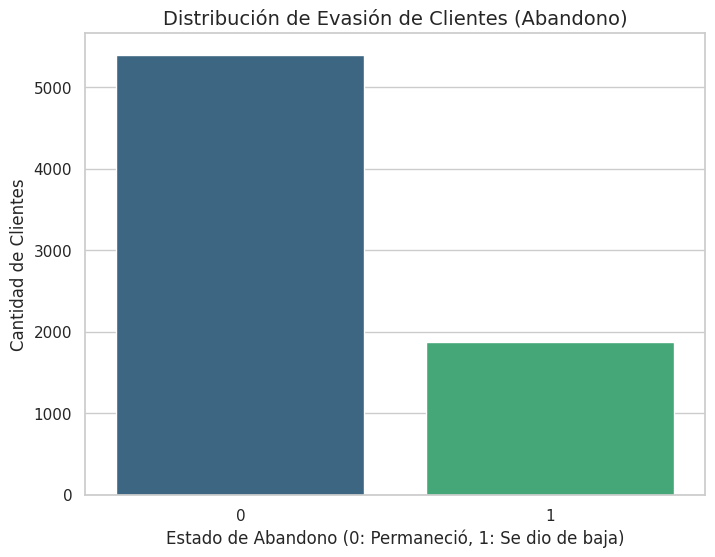

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el estilo de la gráfica
sns.set_theme(style="whitegrid")

# 2. Crear el gráfico de barras para la columna 'Abandono'
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df_flat, x='Abandono', palette='viridis')

# 3. Personalizar títulos y etiquetas
plt.title('Distribución de Evasión de Clientes (Abandono)', fontsize=14)
plt.xlabel('Estado de Abandono (0: Permaneció, 1: Se dio de baja)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# 4. Mostrar el gráfico
plt.show()

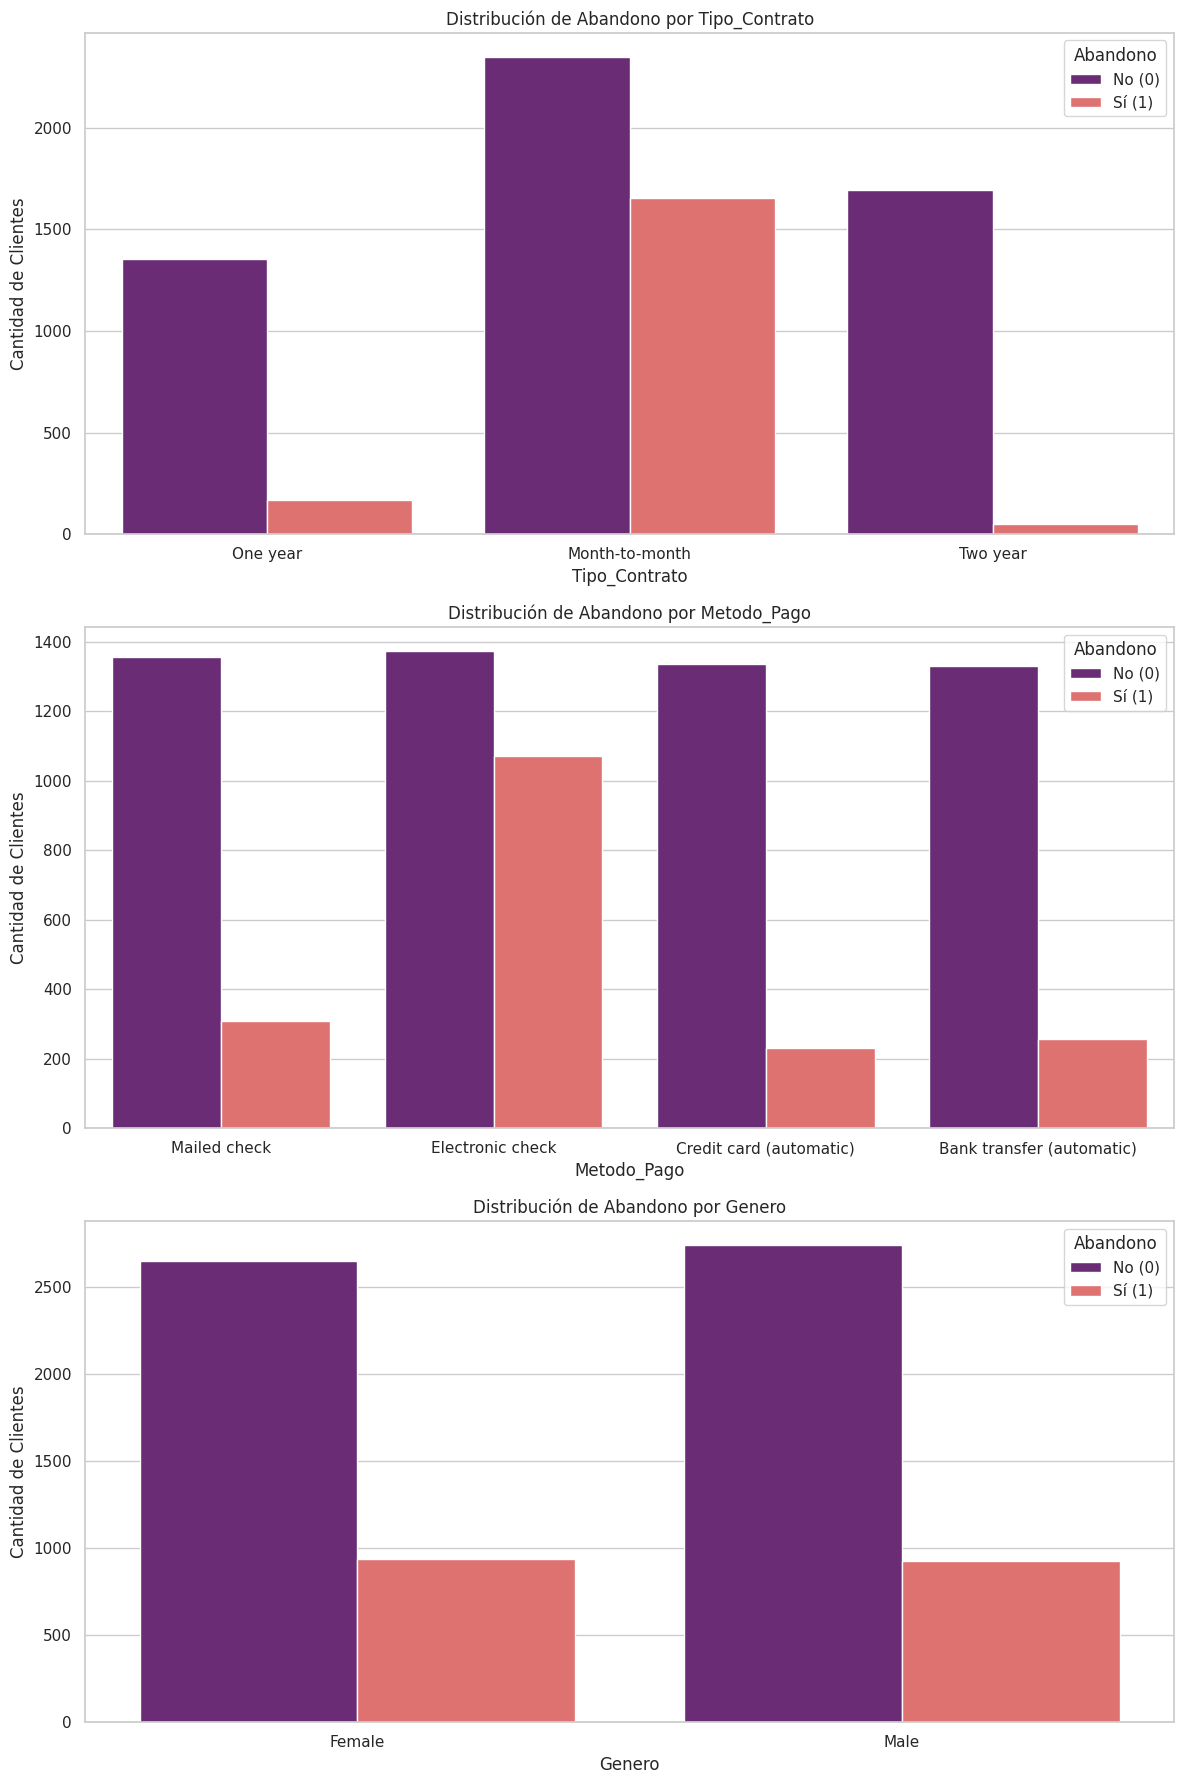

In [14]:
# 1. Definir las variables categóricas a analizar
variables_analizar = ['Tipo_Contrato', 'Metodo_Pago', 'Genero']

# 2. Crear subplots para comparar las variables
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 18))

for i, col in enumerate(variables_analizar):
    sns.countplot(data=df_flat, x=col, hue='Abandono', palette='magma', ax=axes[i])
    axes[i].set_title(f'Distribución de Abandono por {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Cantidad de Clientes')
    axes[i].legend(title='Abandono', labels=['No (0)', 'Sí (1)'])

plt.tight_layout()
plt.show()

/tmp/ipykernel_193/3344269781.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_flat, x='Abandono', y=col, palette='coolwarm', ax=axes[i])
/tmp/ipykernel_193/3344269781.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_flat, x='Abandono', y=col, palette='coolwarm', ax=axes[i])
/tmp/ipykernel_193/3344269781.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_flat, x='Abandono', y=col, palette='coolwarm', ax=axes[i])


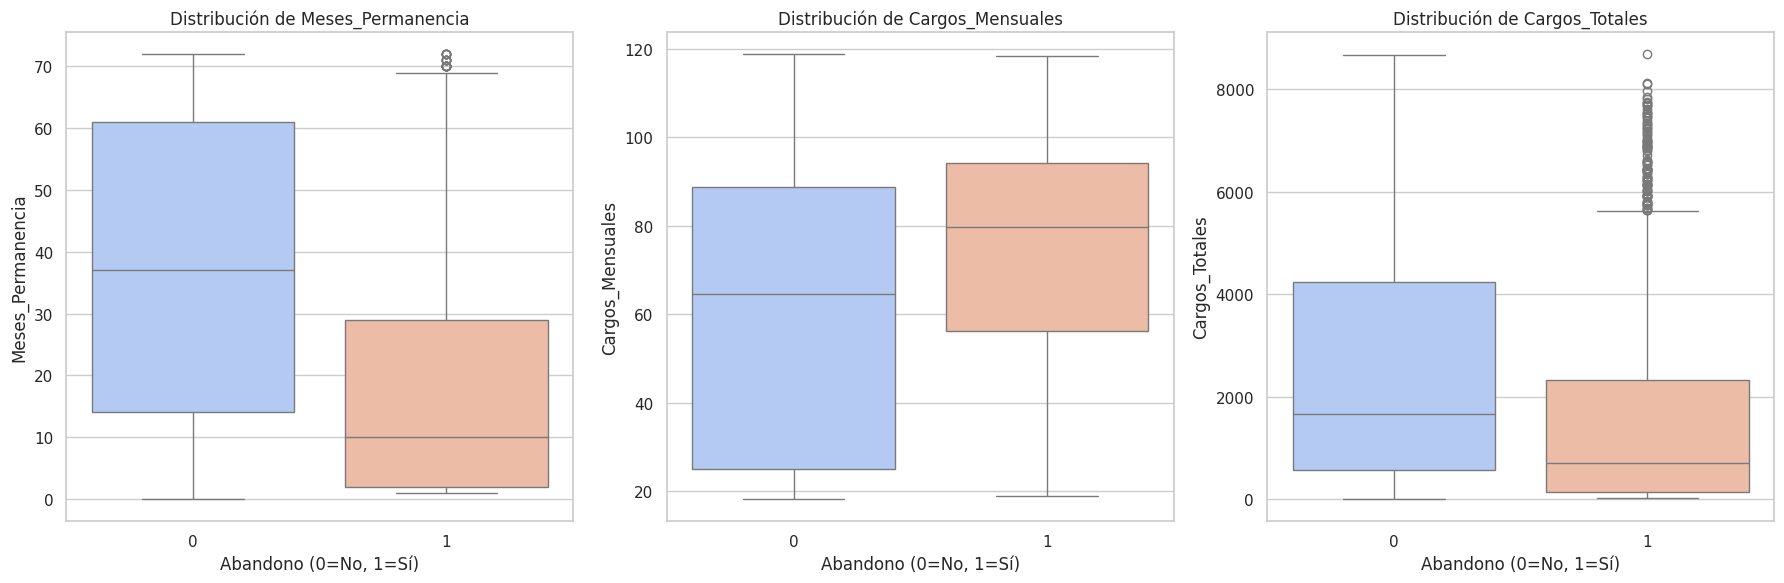

--- Medianas por grupo de Abandono ---


,Meses_Permanencia,Cargos_Mensuales,Cargos_Totales
Abandono,,,
0,37.0,64.50,1663.625
1,10.0,79.65,703.550


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir las variables numéricas clave para la comparación
variables_numericas = ['Meses_Permanencia', 'Cargos_Mensuales', 'Cargos_Totales']

# 2. Crear gráficos de caja (Boxplot) para observar la distribución por Abandono
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for i, col in enumerate(variables_numericas):
    sns.boxplot(data=df_flat, x='Abandono', y=col, palette='coolwarm', ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('Abandono (0=No, 1=Sí)')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# 3. Mostrar las medianas exactas para complementar el gráfico
print("--- Medianas por grupo de Abandono ---")
display(df_flat.groupby('Abandono')[variables_numericas].median())

# Informe de Análisis de Evasión de Clientes - Telecom X

## Introducción
El objetivo de este análisis es identificar los factores que llevan a los clientes de Telecom X a cancelar sus servicios. El problema de evasión de clientes o Churn representa una pérdida directa de ingresos y entenderlo permite diseñar estrategias de retención más efectivas para la compañía.

## Limpieza y Tratamiento de Datos
Durante esta fase, transformamos los datos brutos en información útil para el negocio:
* Se convirtieron los cargos mensuales y totales a formato numérico float64 para permitir cálculos estadísticos precisos.
* Se tradujeron los nombres de las columnas al español para facilitar la lectura del reporte por parte de los interesados.
* La variable Abandono se transformó en valores binarios de 0 y 1 para medir la tasa de evasión con exactitud.
* Se creó la columna Cuentas_Diarias para entender el gasto proporcional por día de cada cliente.

## Análisis Exploratorio de Datos
Mediante las visualizaciones realizadas, identificamos los siguientes patrones críticos:
* La empresa presenta una tasa general de abandono del 25.72%.
* Los clientes con contrato de mes a mes tienen una tendencia de abandono drásticamente superior a los contratos de largo plazo.
* La mayoría de las bajas ocurren de forma temprana, con una mediana de permanencia de solo 10 meses para quienes se van.
* Existe una relación directa entre costos altos y abandono, ya que los clientes que se van pagan en promedio más que los que permanecen.

## Conclusiones e Insights
* Los clientes nuevos son el grupo más vulnerable, especialmente durante su primer año de servicio.
* Los cargos mensuales elevados, superiores a la mediana de 70.00, actúan como un detonante para la salida de los usuarios.
* Los contratos anuales funcionan como la herramienta de retención más efectiva identificada en el dataset.

## Recomendaciones
* Implementar programas de fidelización y bonificaciones especiales para clientes que cumplen sus primeros 6 a 12 meses.
* Crear campañas de incentivos para migrar a los clientes de planes costosos hacia contratos anuales con descuentos.
* Revisar la competitividad de los precios en los servicios que superan los 80.00 mensuales para reducir la fuga por factor económico.

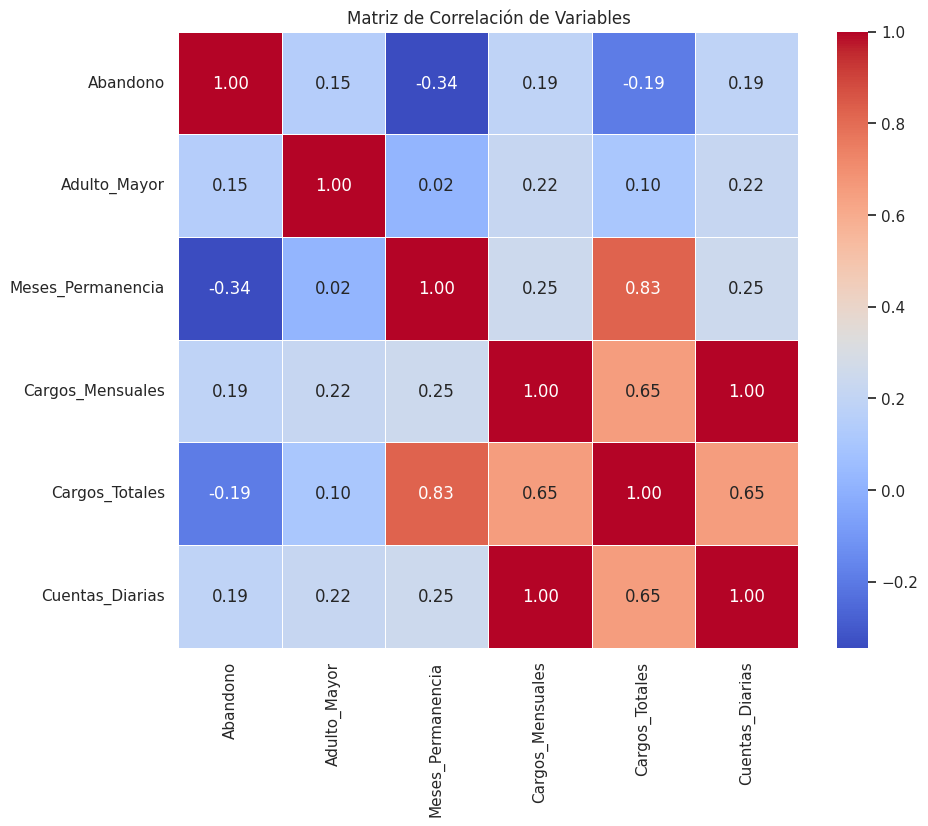

--- Correlación de variables con el Abandono ---
Abandono             1.000000
Cuentas_Diarias      0.189918
Cargos_Mensuales     0.189866
Adulto_Mayor         0.146733
Cargos_Totales      -0.193345
Meses_Permanencia   -0.344079
Name: Abandono, dtype: float64


In [16]:
# 1. Calcular la matriz de correlación solo para variables numéricas
columnas_numericas = ['Abandono', 'Adulto_Mayor', 'Meses_Permanencia', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']
matriz_corr = df_flat[columnas_numericas].corr()

# 2. Visualizar la matriz con un mapa de calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables')
plt.show()

# 3. Correlación específica con la evasión
print("--- Correlación de variables con el Abandono ---")
print(matriz_corr['Abandono'].sort_values(ascending=False))